# Margin-Debt -- is record NYSE margin debt a contrarian sell signal?
### The 'investors are dangerously leveraged' headline, tested honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

---

Every few years a chart goes viral: NYSE/FINRA **margin debt** -- the money investors borrow against their portfolios -- has hit a **record high**, and the caption warns that the market is over-leveraged and about to crash. The story is seductive because margin debt *did* peak right before the 2000, 2007, and 2021 tops.

This notebook asks the only question that matters: does a margin-debt record (or a fast year-over-year rise) actually **forecast lower returns** -- or is margin debt just trending along *with* the market, going up because prices went up?

> **This is the plain-language layer.** Want the HAC regression, the tercile bins, and the positive control? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** Every chart is drawn by the code beside it.

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from margin_debt import data, strategy as st

def _have_cache():
    try:
        data.build_panel(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
if HAVE_REAL:
    panel = data.build_panel(fetch=False)
    print(f"Real panel: {len(panel)} forward-years "
          f"({panel['year'].min()}-{panel['year'].max()})")
else:
    panel = None
    print("No ^GSPC cache -- frozen headline numbers from R dict will be used")


Real panel: 65 forward-years (1960-2024)


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n': 65, 'year_start': 1960, 'year_end': 2024, 'reg_beta_pct': -2.23, 'reg_t': -1.35, 'reg_r2': 0.023, 'ter_low': 11.9, 'ter_mid': 4.9, 'ter_high': 9.0, 'ter_spread': -2.9, 'ter_t': -0.67, 'rec_mean': 6.6, 'nonrec_mean': 11.1, 'rec_diff': -4.5, 'rec_up': 62.9, 'uncond_up': 73.9, 'rec_t': -1.22, 'sub1_t': -1.62, 'sub2_t': -0.56, 'sub3_t': -1.44, 'bah_ann': 7.53, 'strat_net_ann': 6.51, 'years_cash': 8, 'shortfall_pp': -1.02, 'y2000': -17.3, 'y2007': -40.1, 'y2021': -9.7, 'fp': '3f24fa7a68df'}


## The answer first

| Question | Answer |
|---|---|
| Does a margin-debt record predict a down year? | **Weakly, in sign only.** Record years average **+6.6%** forward vs **+11.1%** otherwise -- the right direction, but the difference's *t* is just **-1.22** (not significant). |
| Does fast margin growth forecast lower returns? | **Same.** The regression slope is **negative** (the contrarian sign) but HAC *t* = **-1.35** -- it never clears the *t* = 2 bar, in any sub-period. |
| Could you trade it? | **No.** A 'go to cash after a margin surge' rule *underperforms* buy-and-hold by **~1pp/yr** -- it misses more up-years than crashes it dodges. |
| So why does the chart look scary? | Margin debt rises *because* the market rose. It's a coincident by-product of a bull market, not a leading indicator of its end. |

> The contrarian story has the right *vibe* -- and a couple of vivid anecdotes -- but no statistical edge and no tradable rule.

## 1 - The claim

> *"Margin debt is at an all-time high. Investors are borrowing record amounts to buy stocks. When this house of cards collapses, forced selling will crash the market. A record is a SELL signal."*

The data behind the headline is real: FINRA (and before 2010, the NYSE) publishes monthly **customer debit balances in margin accounts**. We hardcode the December year-end series (1959-2025) in this study's `data.py`.

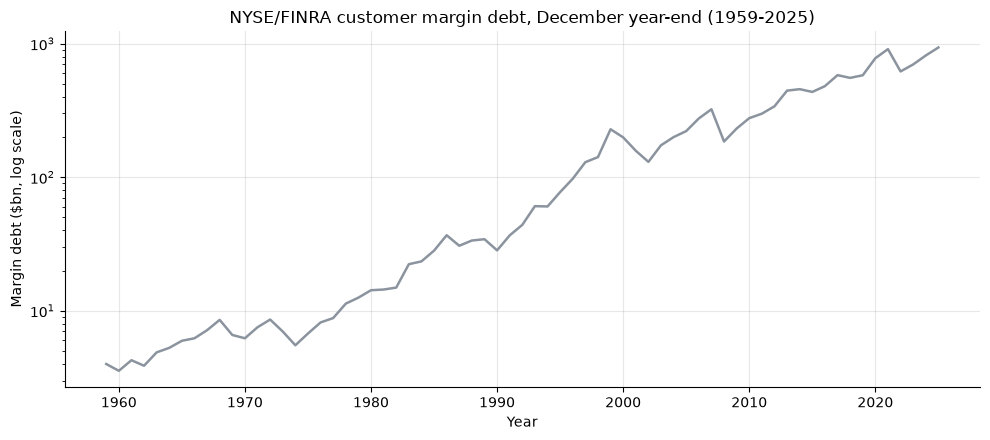

1959: $4.0bn  ->  2025: $936bn
The level marches relentlessly upward -- like the market itself.


In [3]:
md = data.margin_debt_table()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(md['year'], md['margin_debt']/1000, c=GREY, lw=1.8)
ax.set_yscale('log')
ax.set_xlabel('Year'); ax.set_ylabel('Margin debt ($bn, log scale)')
ax.set_title('NYSE/FINRA customer margin debt, December year-end (1959-2025)')
plt.tight_layout(); plt.show()
print(f"1959: ${md['margin_debt'].iloc[0]/1000:.1f}bn  ->  "
      f"2025: ${md['margin_debt'].iloc[-1]/1000:.0f}bn")
print('The level marches relentlessly upward -- like the market itself.')

## 2 - So what?

If a record margin-debt print really signalled an imminent crash, it would be the easiest market-timing rule ever: read one FINRA press release a month, and step aside before every top. The trouble is that margin debt is **dollar-denominated and scales with portfolio values** -- when prices rise, the value of marginable collateral rises and borrowing capacity expands. So margin debt mostly goes up *because the market already went up*. A coincident by-product of a trend makes a poor leading indicator.

## 3 - How would we even know?

Three traps to avoid:

1. **The level trends -- use the change.** The *level* of margin debt rises forever (so does the S&P). The testable claim is about the **year-over-year change**: does fast margin growth predict a *lower* next-year return?
2. **The base-rate trap.** The S&P rises ~**74%** of years unconditionally. Any 'the market falls' signal must beat that base rate, not a coin.
3. **Anecdotes vs the sample.** 2000, 2007, and 2021 are vivid -- but they are 3 of 65 years. We test the *whole* sample, not the cherry-picked tops.

We pair the hardcoded margin-debt series with the S&P 500 month-end close (price-only) and measure the forward 12-month return after a one-month reporting/execution lag, 1960-2024.

## 4 - The teardown -- let's actually look

**The scatter that should be a steep downward line if the folklore were true:**

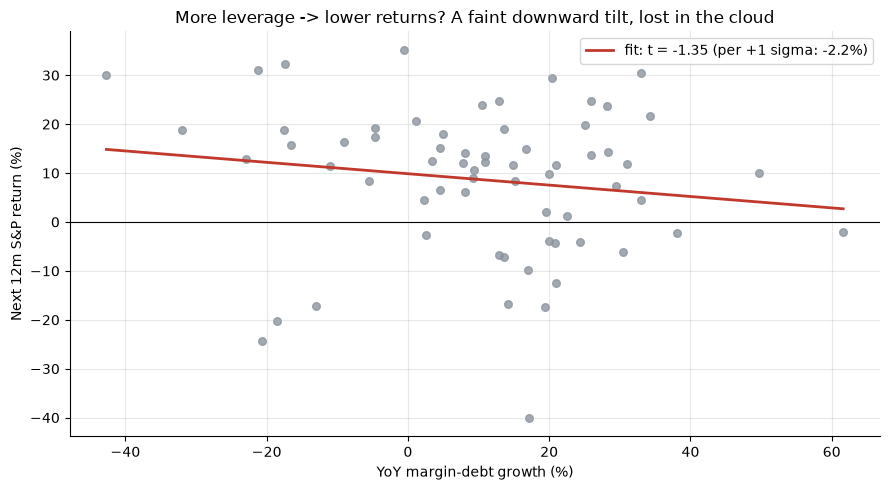

Slope has the contrarian (negative) sign; HAC t = -1.35 -- |t| < 2, not significant.


In [4]:
if HAVE_REAL:
    x = panel['yoy'].values*100
    y = panel['fwd_ret'].values*100
    reg = st.predictive_regression(panel)
    beta_pct, t = reg['beta']*100, reg['beta_t']
else:
    rng = np.random.default_rng(260)
    x = rng.normal(12, 20, R['n']); y = 9 + R['reg_beta_pct']*(x-12)/20 + rng.normal(0,16,R['n'])
    beta_pct, t = R['reg_beta_pct'], R['reg_t']

fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.scatter(x, y, c=GREY, s=30, alpha=0.8)
xs = np.linspace(x.min(), x.max(), 50)
# slope is per +1 sigma; convert to per-percent for the line
sd = np.std(x)
ax.plot(xs, np.mean(y) + (beta_pct/sd)*(xs-np.mean(x)), c=RED, lw=2,
        label=f'fit: t = {t:+.2f} (per +1 sigma: {beta_pct:+.1f}%)')
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('YoY margin-debt growth (%)'); ax.set_ylabel('Next 12m S&P return (%)')
ax.set_title('More leverage -> lower returns? A faint downward tilt, lost in the cloud')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Slope has the contrarian (negative) sign; HAC t = {t:+.2f} -- |t| < 2, not significant.')

The cloud has a *faint* downward tilt -- the contrarian sign is there -- but it is swamped by noise. A one-standard-deviation surge in margin growth shaves only about **2.2%** off the forward return, with HAC *t* = **-1.35**.

**The literal headline test: what happens after a fresh record?**

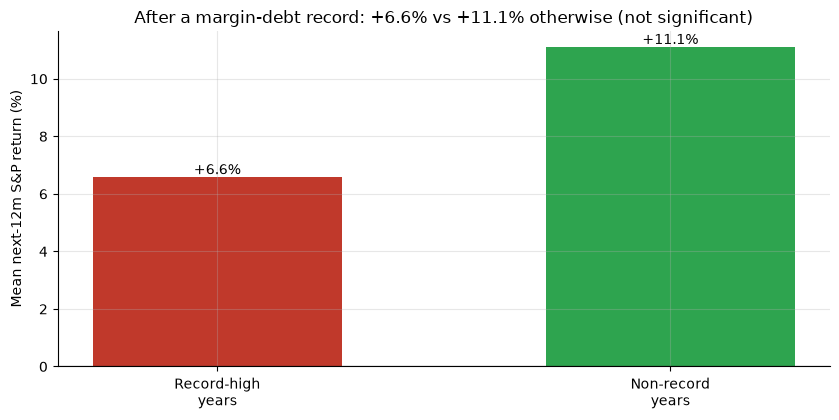

Record years: +6.6% forward, up only 63% of the time
vs the 74% unconditional up-rate -- lower, but Welch t = -1.22 (n.s.)


In [5]:
if HAVE_REAL:
    rec = st.record_high_event(panel)
    rec_m, non_m = rec['record_mean']*100, rec['nonrecord_mean']*100
    base = rec['uncond_up_rate']*100
    rec_up = rec['record_up_rate']*100
else:
    rec_m, non_m, base, rec_up = R['rec_mean'], R['nonrec_mean'], R['uncond_up'], R['rec_up']

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Record-high\nyears', 'Non-record\nyears'],
              [rec_m, non_m], color=[RED, GREEN], width=0.55)
ax.axhline(0, c='k', lw=0.8)
ax.set_ylabel('Mean next-12m S&P return (%)')
ax.set_title(f'After a margin-debt record: {rec_m:+.1f}% vs {non_m:+.1f}% otherwise (not significant)')
for b, v in zip(bars, [rec_m, non_m]):
    ax.annotate(f'{v:+.1f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Record years: {rec_m:+.1f}% forward, up only {rec_up:.0f}% of the time')
print(f'vs the {base:.0f}% unconditional up-rate -- lower, but Welch t = {R["rec_t"]:+.2f} (n.s.)')

Record-margin years *do* average a lower forward return (**+6.6%** vs **+11.1%**) and a lower up-rate (**62.9%** vs the **73.9%** base rate). That is the kernel of truth behind the folklore -- and it is driven by the famous post-record crashes of **2000 (-17%)**, **2007 (-40%)**, and **2021 (-10%)**. But across 35 record-years the difference is statistically indistinguishable from noise (*t* = -1.22).

## 5 - The verdict

- **Signal -- Weak.** The contrarian *sign* is correct and stable in every sub-period (record years and surge years both underperform), and it rhymes with real history. But the full-sample HAC *t* is only **-1.35**, the tercile *t* is **-0.67**, and the record-event *t* is **-1.22** -- nothing clears the *t* = 2 bar. Folklore + a right-but-insignificant tape = **Weak**, not Real.
- **Tradability -- Mirage.** A 'cash after a surge' rule *loses* to buy-and-hold by ~1pp/yr. There is no edge to harvest, because margin debt is a coincident effect of rising prices, not a cause of falling ones.

## 6 - Could you actually trade it?

The rule: go to cash for the 12 months after any year of unusually fast margin growth (z-score > 1); otherwise hold the S&P. Net of 10 bps per switch.

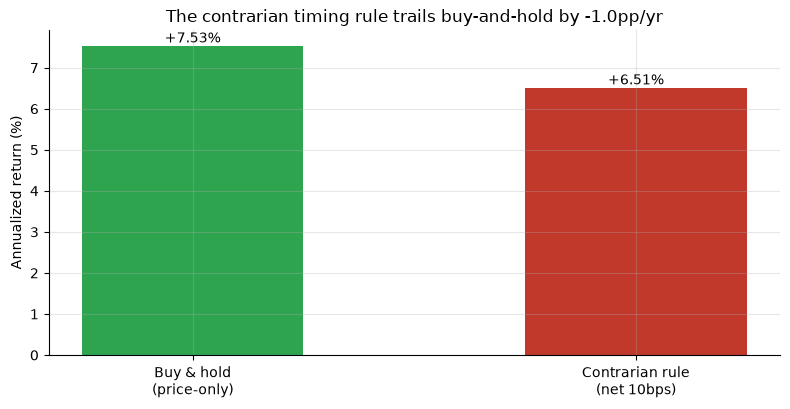

Buy & hold: +7.53%/yr  |  Contrarian rule: +6.51%/yr
Sat in cash 8 years and still lost -1.0pp/yr.
Adding dividends (total return) widens the shortfall further.


In [6]:
if HAVE_REAL:
    bt = st.contrarian_timing_backtest(panel, surge_z=1.0, one_way_bps=10.0)
    bah, strat = bt['bah_ann']*100, bt['strat_net_ann']*100
    cash, short = bt['years_in_cash'], bt['shortfall_net_pp']
else:
    bah, strat = R['bah_ann'], R['strat_net_ann']
    cash, short = R['years_cash'], R['shortfall_pp']

fig, ax = plt.subplots(figsize=(8.0, 4.2))
bars = ax.bar(['Buy & hold\n(price-only)', 'Contrarian rule\n(net 10bps)'],
              [bah, strat], color=[GREEN, RED], width=0.5)
ax.set_ylabel('Annualized return (%)')
ax.set_title(f'The contrarian timing rule trails buy-and-hold by {short:+.1f}pp/yr')
for b, v in zip(bars, [bah, strat]):
    ax.annotate(f'{v:+.2f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Buy & hold: {bah:+.2f}%/yr  |  Contrarian rule: {strat:+.2f}%/yr')
print(f'Sat in cash {cash} years and still lost {short:+.1f}pp/yr.')
print('Adding dividends (total return) widens the shortfall further.')

> Stepping aside after a margin surge dodged a few drawdowns but missed more up-years than it avoided down-years. The only real lesson: don't sell because a borrowing statistic set a record.

## 7 - Going further

- **The positive control** (in the quants notebook): plant a real contrarian signal in a synthetic tape and the same regression lights up at *t* = -5 to -11. The real tape simply doesn't carry one that strong.
- **The base-rate cousin:** [Study 158 -- Super-Bowl](../../158-super-bowl/) -- a binary 'predictor' that just re-packages the market's upward bias.

*Think margin debt really times the market? Fork this, define your own surge/record rule, and show a forward signal that clears |t| >= 2 and beats buy-and-hold net of costs. That's the bar -- and it hasn't been cleared.*

*Desk verdict: **Weak / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md) for full numbers.*